# Libraries & Setup

In [ ]:
import pandas as pd
import numpy as np
import re
import os
import nltk
import matplotlib.pyplot as plt
import seaborn
import regex as re
import torch
import torch.nn.functional as F

from pathlib import Path
from nltk.probability import FreqDist
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import ngrams
from nltk import bigrams as make_bigrams
from collections import Counter
from tqdm.auto import tqdm
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr
from sklearn.metrics import cohen_kappa_score
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from locale import normalize

In [2]:
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Datasets

## Creation

In [3]:
def create_speeches_df(root_dir):
    root_dir = Path(root_dir)
    data = []

    # Iter for the folders inside TXT
    for subfolder in sorted(root_dir.iterdir()):
        if not subfolder.is_dir():
            continue

        # Extract session number and year from the folder name, e.g. "Session 25 - 1970"
        match = re.match(r"Session (\d+) - (\d+)", subfolder.name)
        if not match:
            continue  # skip anything that doesn't match the expected pattern
        session_number, year = int(match.group(1)), int(match.group(2))

        for file in subfolder.iterdir():
            if not file.is_file() or file.name.startswith("."):
                continue

            country_code = file.name.split("_")[0]
            with open(file, encoding="utf-8") as f:
                speech_text = f.read()

            data.append([session_number, year, country_code, speech_text])

    return pd.DataFrame(data, columns=['session_number', 'year', 'country_code', 'speech_text'])

In [4]:
def create_df_from_csv(file_path,sep=','):
    df = pd.read_csv(file_path, sep=sep)
    return df

In [ ]:
def get_text_data(output=False, N=False):
    """
    gets all the text data from the subfolders, can print it and you can limit the number of prints
    returns a dictionary with key the title of the file and value the text of the file
    """
    subfolders = []
    for folder in os.listdir('data/TXT'):
        if os.path.isdir(os.path.join('data/TXT', folder)):
            subfolders.append(folder)

    text_data = {}
    for folder in subfolders:
        for file in os.listdir(os.path.join('data/TXT', folder)):
            if file.endswith('.txt'):
                with open(os.path.join('data/TXT', folder, file), 'r') as f:
                    text_data[file] = f.read()
                    if output:
                        print(f"Title: {file}")
                        print(f"Text: {text_data[file]}")
                        print("\n")
                    if N and len(text_data) >= N:
                        return text_data
    return text_data

#test with first file
text_data = get_text_data()
print(text_data["ARG_01_1946.txt"])

In [5]:
df_speeches_raw = create_speeches_df('data/TXT')
display(df_speeches_raw.info())
display(df_speeches_raw.sample(10))

<class 'pandas.DataFrame'>
RangeIndex: 11141 entries, 0 to 11140
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   session_number  11141 non-null  int64
 1   year            11141 non-null  int64
 2   country_code    11141 non-null  str  
 3   speech_text     11141 non-null  str  
dtypes: int64(2), str(2)
memory usage: 348.3 KB


None

,session_number,year,country_code,speech_text
2588,32,1977,VEN,"﻿97.\t Mr. President, it is particularly pleas..."
9312,71,2016,TZA,"First and foremost, I would like to convey to ..."
1908,27,1972,MLT,"Mr. President, may I first of all be allowed t..."
11005,80,2025,BEL,The Assembly will hear and address by His Exce...
3591,39,1984,BEN,﻿It is a signal honour for me to speak for the...
4381,44,1989,MRT,"﻿I have pleasure in extending to Mr. Garba, of..."
0,1,1946,LBR,I give you the greetings of the Government and...
4819,47,1992,BTN,I have the honour to convey to you and to \nal...
9262,71,2016,SWZ,I bring warm and fraternal greetings from His ...
4931,48,1993,LCA,"May I at the outset\nextend to you, Sir, my ow..."


In [ ]:
gdp = pd.read_csv("data/GDP.csv")

In [ ]:
renewable_energy = pd.read_csv("data/API_EG.FEC.RNEW.ZS_DS2_en_csv_v2_372598.csv")

## Cleaning and Preproccessing

In [8]:
# Module to track progress bar
tqdm.pandas()

In [9]:
# Reset index
df_speeches = df_speeches_raw.set_index(['year','country_code'])

# Drop session column
df_speeches.drop(columns=['session_number'],inplace=True)

# Lowercase the speec
df_speeches['speech_text'] = df_speeches['speech_text'].str.lower()

# Remove special characters
df_speeches['speech_text'] = (
    df_speeches['speech_text']
    .str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [10]:
# Remove stop words
stop = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    new_text = [t for t in tokens if t not in stop]
    return new_text

# Tokenize
df_speeches['tokens'] = df_speeches['speech_text'].progress_apply(remove_stopwords)

  0%|          | 0/11141 [00:00<?, ?it/s]

We decided to process the speeches by doing a lower case, removal of special characters and numbers. After that performing tokenization by removing as well the english stop words.
The result is a list clean tokens for each speech.

In [11]:
# Lemmatize
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    lemmatized = []
    for t in tokens:
        lemmatized.append(lemmatizer.lemmatize(t))
    return lemmatized

df_speeches['lemmatization'] = df_speeches['tokens'].progress_apply(lemmatize_tokens)

  0%|          | 0/11141 [00:00<?, ?it/s]

The decision of using a lemmatizer is based on creating the best standarization of the tokens. This lemmatizer will treat each token as a sustantive and try to turn plural words into singular (e.g. disasters -> disaster). Also in the future it will help the model to have fewer words to iterate over as the same word in plural and singular are transformed into the same token. 

In [12]:
# Determine the length of the speeches
df_speeches['speech_length'] = (
    df_speeches['speech_text']
    .str.split()
    .str.len()
)
df_speeches['tokens_length'] = df_speeches['tokens'].str.len()

In [13]:
df_speeches.sample(5)

,,speech_text,tokens,lemmatization,speech_length,tokens_length
year,country_code,,,,,
1959,LKA,sir claude corea ceylon apart from the tribute...,"[sir, claude, corea, ceylon, apart, tribute, p...","[sir, claude, corea, ceylon, apart, tribute, p...",8676,4242
2015,GHA,let me congratulate the secretary general the ...,"[let, congratulate, secretary, general, staff,...","[let, congratulate, secretary, general, staff,...",2668,1356
2023,LIE,we gather this year under ever more daunting c...,"[gather, year, ever, daunting, challenges, win...","[gather, year, ever, daunting, challenge, wind...",1935,972
2024,LCA,distinguished mr president i begin my address ...,"[distinguished, mr, president, begin, address,...","[distinguished, mr, president, begin, address,...",2091,1088
2014,JPN,humankind faces serious unprecedented crises n...,"[humankind, faces, serious, unprecedented, cri...","[humankind, face, serious, unprecedented, cris...",2418,1308


It is clear how the tokenization and cleaning reduces the length of every speech, reducing noise in every text.

In [ ]:
year_cols = [c for c in gdp.columns if c.isdigit()]
gdp_long = gdp.melt(
    id_vars=["Country Code"],
    value_vars=year_cols,
    var_name="year",
    value_name="gdp",
)

# 3. Clean types and column names
gdp_long["year"] = gdp_long["year"].astype(int)
gdp_long["country"] = gdp_long["Country Code"].str.strip().str.upper()
gdp_long["gdp"] = pd.to_numeric(gdp_long["gdp"], errors="coerce")

# 4. Filter positive values & compute logarithm
gdp_long = gdp_long[gdp_long["gdp"] > 0].copy()
gdp_long["log_gdp"] = np.log(gdp_long["gdp"])

# 5. Extract clean panel dataframe
df_gdp_clean = gdp_long[["country", "year", "gdp", "log_gdp"]].reset_index(drop=True)

# 6. (Optional) Lookup series for O(1) access
gdp_lookup = df_gdp_clean.set_index(["country", "year"])["log_gdp"]

In [ ]:
renewable_energy.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 70"], inplace=True)
share_of_total_emmissions = pd.read_csv("data/share-of-cumulative-co2.csv")
share_of_total_emmissions.rename(columns={"Code": "country", "Year":"year", "Share of global cumulative CO₂ emissions": "share co2"}, inplace=True)
share_of_total_emmissions

# Exploratory

## Speeches

### Length

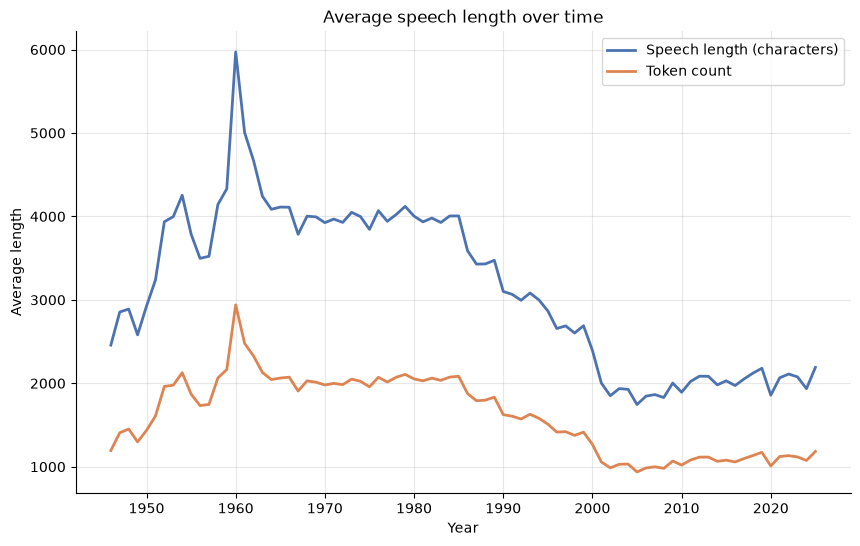

In [14]:
# Lengths of speeches accross time
avg_lengths = df_speeches.groupby(level='year')[['speech_length', 'tokens_length']].mean()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(avg_lengths.index, avg_lengths['speech_length'],
        color='#4C72B0', linewidth=2, label='Speech length (characters)')
ax.plot(avg_lengths.index, avg_lengths['tokens_length'],
        color='#DD8452', linewidth=2, label='Token count')

ax.set_xlabel('Year')
ax.set_ylabel('Average length')
ax.set_title('Average speech length over time')

ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

### ngrams

In this section the objective is to determine the appereances of key words in each speech using ngrams.

In [15]:
df_ngrams = df_speeches.copy()

In [16]:
# Unigrams
unigrams = {
    'warming','carbon','dioxide','emissions','greenhouse','fossil','methane','ozone','atmosphere',
    'drought','wildfires','flooding','deforestation',
    'climate','weather','renewable'
    }

First we start with intuitive set of words related to climate change, that we overwrite depending on the results we encounter.

In [17]:
# Corpus pairs
ngrams_2 = Counter(p for toks in df_speeches['lemmatization'] for p in make_bigrams(toks))

With the help of make_bigrams we create the list of most common bigrams over all the speeches.

In [18]:
ngrams_2.most_common(1000)

[(('united', 'nation'), 153392),
 (('general', 'assembly'), 40975),
 (('international', 'community'), 32681),
 (('security', 'council'), 29182),
 (('human', 'right'), 26551),
 (('secretary', 'general'), 24832),
 (('united', 'state'), 23387),
 (('developing', 'country'), 22784),
 (('peace', 'security'), 20834),
 (('co', 'operation'), 20264),
 (('middle', 'east'), 15548),
 (('member', 'state'), 14229),
 (('south', 'africa'), 14030),
 (('session', 'general'), 13007),
 (('nuclear', 'weapon'), 12338),
 (('economic', 'social'), 11609),
 (('climate', 'change'), 10876),
 (('sustainable', 'development'), 10644),
 (('international', 'peace'), 10599),
 (('per', 'cent'), 10030),
 (('developed', 'country'), 9940),
 (('would', 'like'), 9416),
 (('soviet', 'union'), 8801),
 (('self', 'determination'), 8539),
 (('international', 'law'), 8271),
 (('international', 'economic'), 7070),
 (('viet', 'nam'), 6984),
 (('people', 'republic'), 6940),
 (('international', 'relation'), 6673),
 (('last', 'year'), 6

In [19]:
# Test for different words the most common bigrams
[(p, c) for p, c in ngrams_2.most_common(10000) if "energy" in p][:30]

[(('atomic', 'energy'), 1307),
 (('renewable', 'energy'), 720),
 (('nuclear', 'energy'), 651),
 (('energy', 'agency'), 595),
 (('source', 'energy'), 412),
 (('energy', 'resource'), 360),
 (('energy', 'crisis'), 310),
 (('food', 'energy'), 266),
 (('energy', 'source'), 222),
 (('energy', 'security'), 210),
 (('energy', 'peaceful'), 199),
 (('clean', 'energy'), 192),
 (('energy', 'transition'), 165),
 (('sustainable', 'energy'), 156),
 (('energy', 'food'), 137)]

With the use of the previous cell, for each unigram we find the most common pairs that are related to the topic, and manually determine which ones we are going to consider as the bigrams to continue or exploration.

In [20]:
# Bigrams
bigrams = {
    # Energy
    ('renewable', 'energy'),('energy', 'resource'),('energy', 'crisis'),
    ('energy', 'source'),('clean', 'energy'),('sustainable', 'energy'),
    # Climate
    ('climate', 'change'),('climate', 'crisis'),
    # Carbon
    ('carbon','dioxide'),('carbon','emission'),
    # Other
    ('global','warming'),('carbon','dioxide'),('extreme','weather'),
    ('greenhouse','gas'),('greenhouse','gases'),('natural','disasters'),
    ('fossil','fuels'),('gas', 'emission'),
    # Natural
    ('natural', 'resource'),('natural', 'disaster')
   }

In [21]:
# Count appereances in speeches
def count_terms(tokens):
    uni = sum(1 for u in tokens if u in unigrams)
    bi = sum(1 for b in make_bigrams(tokens) if b in bigrams)
    return pd.Series({'unigram_count':uni, 'bigram_count':bi})

df_ngrams[['unigram_count','bigram_count']]= df_ngrams['lemmatization'].progress_apply(count_terms)

  0%|          | 0/11141 [00:00<?, ?it/s]

In [22]:
# See the speech with the higher count
df_ngrams.sort_values('unigram_count',ascending=False)['speech_text'].iloc[0]

'last friday ushered in a new era in our search for an innovative plan of action for people and the planet the significant milestone event was the adoption by the united nations of the new set of sustainable development goals as part of the agenda for sustainable development resolution our sustainable development goals are inspirational and ambitious they are global in nature and universally applicable to every united nations member state developed and developing alike every goal is important and deserves priority attention they are interrelated they carry equal weight and they all matter achieving some goals at the expense of others is not a preferred option all goals must be realized which should be the overriding objective in my firm belief in the importance of the work of our organization i have tried to attend the annual general assembly debates as often as possible since becoming samoa s prime minister i am therefore acutely aware of the diversity and gravity of issues confrontin

In [23]:
# Determine if a speech has or not unigrams or bigrams
df_ngrams['has_unigram'] = df_ngrams['unigram_count'].apply(lambda x: 1 if x > 0 else 0)
df_ngrams['has_bigram'] = df_ngrams['bigram_count'].apply(lambda x: 1 if x > 0 else 0)

In [24]:
# Rate of mentions per speech
df_ngrams['unigram_rate'] = df_ngrams['unigram_count']/df_ngrams['tokens_length']*1000
df_ngrams['bigram_rate'] = df_ngrams['bigram_count']/df_ngrams['tokens_length']*1000

Create ratios over 1000 words to standarize both metrics.

In [25]:
# Agroupation by year

# Option A mean of ratios
yearly_A = df_ngrams.groupby('year')[['unigram_rate','bigram_rate']].mean()

# Option general proportion
yearly_B = df_ngrams.groupby('year')[['unigram_count','bigram_count','tokens_length']].sum()
yearly_B['yearly_unigram_rate'] = yearly_B['unigram_count']/yearly_B['tokens_length']*1000
yearly_B['yearly_bigram_rate'] = yearly_B['bigram_count']/yearly_B['tokens_length']*1000

# Option to count countries that incorporated terms in their speeches
yearly_C = df_ngrams.groupby('year')[['has_unigram','has_bigram']].sum()


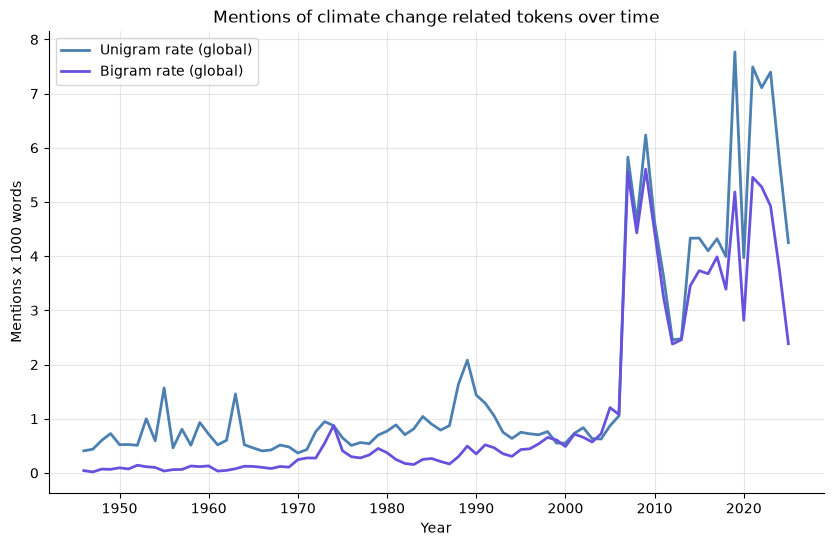

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

# ax.plot(yearly_A.index, yearly_A['unigram_rate'],
#         color="#B08F4C", linewidth=2, label='Unigram rate (mean of means)')
# ax.plot(yearly_A.index, yearly_A['bigram_rate'],
#         color="#DD9152", linewidth=2, label='Bigram rate (mean of means)')

ax.plot(yearly_B.index, yearly_B['yearly_unigram_rate'],
        color="#4C80B0", linewidth=2, label='Unigram rate (global)')
ax.plot(yearly_B.index, yearly_B['yearly_bigram_rate'],
        color="#6752DD", linewidth=2, label='Bigram rate (global)')

ax.set_xlabel('Year')
ax.set_ylabel('Mentions x 1000 words')
ax.set_title('Mentions of climate change related tokens over time')

ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

We can see that the unigram rate is higher than the bigram rate, basically because unigrams can bring flags on keywords that might be used in other context. Meanwhile the bigrams are more restricted and only show the exact bigram that we determined.

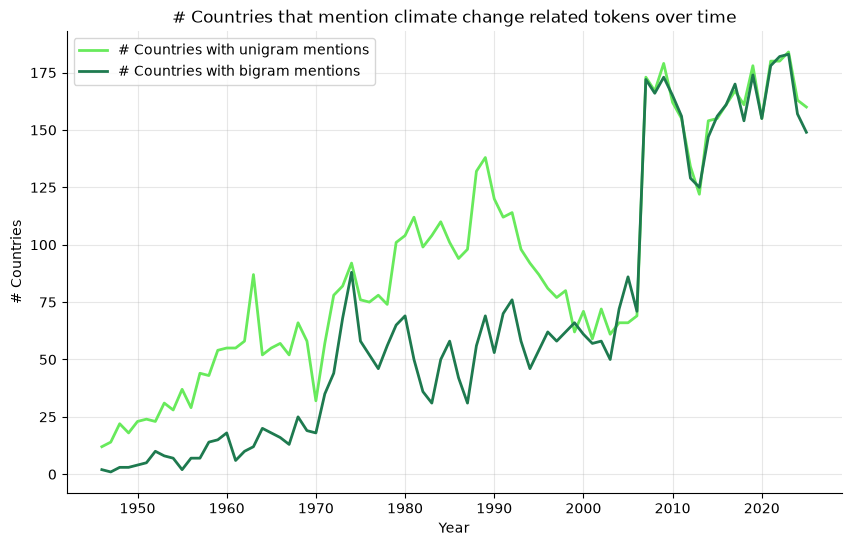

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(yearly_C.index, yearly_C['has_unigram'],
        color="#68EA5C", linewidth=2, label='# Countries with unigram mentions')
ax.plot(yearly_C.index, yearly_C['has_bigram'],
        color="#1E7A4F", linewidth=2, label='# Countries with bigram mentions')

ax.set_xlabel('Year')
ax.set_ylabel('# Countries')
ax.set_title('# Countries that mention climate change related tokens over time')

ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

### Climate change vs energy frequency

In [29]:
df_cc_vs_re = df_speeches.copy()

In [30]:
# Bigrams

# Energy
re_bigrams = {
    # Energy
    ('renewable', 'energy'),('energy', 'resource'),('energy', 'crisis'),
    ('energy', 'source'),('clean', 'energy'),('sustainable', 'energy')
   }

# Climate change
cc_bigrams = {
    # Climate
        ('climate', 'change'),('climate', 'crisis'),
        # Carbon
        ('carbon','dioxide'),('carbon','emission'),
        # Other
        ('global','warming'),('extreme','weather'),
        ('greenhouse','gas'),
        ('fossil','fuel'),('gas', 'emission'),
        # Natural
        ('natural', 'resource'),('natural', 'disaster')
    }

We proceed by making a division of climate related topics and renewable energy related topics, only using bigrams because that is what we determined on previous steps. The use of bigrams is more accurate than unigrams to determine the usage of keywords on the specific context.

In [31]:
# Count appereances in speeches
def count_vs_terms(tokens):
    energy = sum(1 for t in make_bigrams(tokens) if t in re_bigrams)
    climate = sum(1 for t in make_bigrams(tokens) if t in cc_bigrams)
    return pd.Series({'renewable_energy_count':energy, 'climate_change_count':climate})

df_cc_vs_re[['renewable_energy_count','climate_change_count']]= df_cc_vs_re['lemmatization'].progress_apply(count_vs_terms)

  0%|          | 0/11141 [00:00<?, ?it/s]

In [32]:
df_cc_vs_re[['renewable_energy_count','climate_change_count']].sum()

renewable_energy_count     1960
climate_change_count      18658
dtype: int64

In [33]:
# Determine if a speech has or not energy or climate bigrams
df_cc_vs_re['has_renewable_energy'] = df_cc_vs_re['renewable_energy_count'].apply(lambda x: 1 if x > 0 else 0)
df_cc_vs_re['has_climate_change'] = df_cc_vs_re['climate_change_count'].apply(lambda x: 1 if x > 0 else 0)

In [34]:
# Rate of mentions per speech
df_cc_vs_re['renewable_energy_1000_rate'] = df_cc_vs_re['renewable_energy_count']/df_cc_vs_re['tokens_length']*1000
df_cc_vs_re['climate_change_1000_rate'] = df_cc_vs_re['climate_change_count']/df_cc_vs_re['tokens_length']*1000

In [35]:
# Group by year rate
yearly_vs = df_cc_vs_re.groupby('year')[['renewable_energy_count','climate_change_count','tokens_length']].sum()
yearly_vs['yearly_renewable_energy_rate'] = yearly_vs['renewable_energy_count']/yearly_vs['tokens_length']*1000
yearly_vs['yearly_climate_change_rate'] = yearly_vs['climate_change_count']/yearly_vs['tokens_length']*1000

# Group by year country
yearly_country_vs = df_cc_vs_re.groupby('year')[['has_renewable_energy','has_climate_change']].sum()

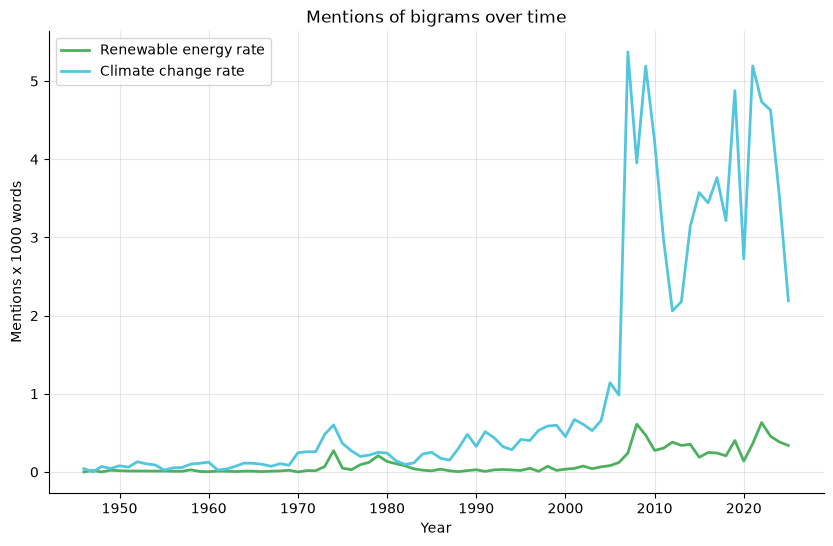

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(yearly_vs.index, yearly_vs['yearly_renewable_energy_rate'],
        color="#4CB05E", linewidth=2, label='Renewable energy rate')
ax.plot(yearly_vs.index, yearly_vs['yearly_climate_change_rate'],
        color="#52C6DD", linewidth=2, label='Climate change rate')

ax.set_xlabel('Year')
ax.set_ylabel('Mentions x 1000 words')
ax.set_title('Mentions of bigrams over time')

ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

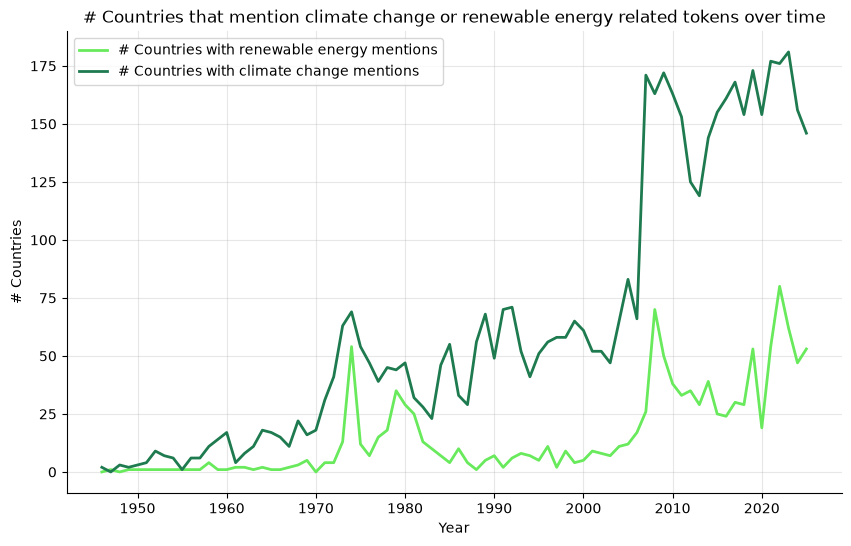

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(yearly_country_vs.index, yearly_country_vs['has_renewable_energy'],
        color="#68EA5C", linewidth=2, label='# Countries with renewable energy mentions')
ax.plot(yearly_country_vs.index, yearly_country_vs['has_climate_change'],
        color="#1E7A4F", linewidth=2, label='# Countries with climate change mentions')

ax.set_xlabel('Year')
ax.set_ylabel('# Countries')
ax.set_title('# Countries that mention climate change or renewable energy related tokens over time')

ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [38]:
# Create a df to measure each bigram frequency
df_bigram_frequency = df_cc_vs_re.copy()

In [39]:
# Create a column for each bigram (per-speech count)
lemmatized_tokens = df_bigram_frequency['lemmatization']

for bigram in re_bigrams:
    new_column = 'token_' + "_".join(bigram) + '_count'
    df_bigram_frequency[new_column] = lemmatized_tokens.apply(
        lambda tokens: sum(1 for b in make_bigrams(tokens) if b == bigram)
    )

for bigram in cc_bigrams:
    new_column = 'token_' + "_".join(bigram) + '_count'
    df_bigram_frequency[new_column] = lemmatized_tokens.apply(
        lambda tokens: sum(1 for b in make_bigrams(tokens) if b == bigram)
    )

df_bigram_frequency

speech_text  \
year country_code                                                      
1946 LBR           i give you the greetings of the government and...   
     UKR           the day before yesterday the head of the deleg...   
     IRN           during the first part of the first session of ...   
     CAN           if were not anxious like all my colleagues to ...   
     HTI           a new world is being born from the fragments o...   
...                                                              ...   
2025 KGZ           the assembly will now hear an address by his e...   
     LBN           the assembly will hear and address by his exce...   
     AUS           now the assembly will hear an address by his e...   
     NLD           the assembly will now hear an address by his e...   
     TGO           i now give the floor to his excellency mr robe...   

                                                              tokens  \
year country_code                                                      
1946 LBR           [give, greetings, government, people, liberia,...   
     UKR           [day, yesterday, head, delegation, union, sovi...   
     IRN           [first, part, first, session, general, assembl...   
     CAN           [anxious, like, colleagues, take, consideratio...   
     HTI           [new, world, born, fragments, world, torn, asu...   
...                                                              ...   
2025 KGZ           [assembly, hear, address, excellency, sadra, s...   
     LBN           [assembly, hear, address, excellency, joseph, ...   
     AUS           [assembly, hear, address, excellency, antony, ...   
     NLD           [assembly, hear, address, excellency, dick, sk...   
     TGO           [give, floor, excellency, mr, robert, kholan, ...   

                                                       lemmatization  \
year country_code                                                      
1946 LBR           [give, greeting, government, people, liberia, ...   
     UKR           [day, yesterday, head, delegation, union, sovi...   
     IRN           [first, part, first, session, general, assembl...   
     CAN           [anxious, like, colleague, take, consideration...   
     HTI           [new, world, born, fragment, world, torn, asun...   
...                                                              ...   
2025 KGZ           [assembly, hear, address, excellency, sadra, s...   
     LBN           [assembly, hear, address, excellency, joseph, ...   
     AUS           [assembly, hear, address, excellency, antony, ...   
     NLD           [assembly, hear, address, excellency, dick, sk...   
     TGO           [give, floor, excellency, mr, robert, kholan, ...   

                   speech_length  tokens_length  renewable_energy_count  \
year country_code                                                         
1946 LBR                    1606            796                       0   
     UKR                    4266           2070                       0   
     IRN                     534            240                       0   
     CAN                    1523            734                       0   
     HTI                     484            240                       0   
...                          ...            ...                     ...   
2025 KGZ                    2856           1582                       0   
     LBN                    2455           1282                       0   
     AUS                    2431           1226                       4   
     NLD                    1612            814                       0   
     TGO                    3182           1607                       0   

                   climate_change_count  has_renewable_energy  \
year country_code                                               
1946 LBR                              0                     0   
     UKR                              0                     0   
     IRN  

## BERT

In [47]:
# Dictionary with climate related topcics
climate_words_dict = {"greenhouse_gases_and_emissions": [
        "carbon dioxide", "co2", "methane", "ch4", "nitrous oxide", "n2o",
        "fluorinated gases", "greenhouse effect", "carbon emissions",
        "scope 1 emissions", "scope 2 emissions", "scope 3 emissions",
        "carbon footprint", "carbon budget", "emission intensity", "flaring"
    ],
    "climate_science_and_phenomena": [
        "global warming", "surface temperature", "temperature anomaly",
        "radiative forcing", "albedo effect", "feedback loop", "tipping point",
        "keeling curve", "ocean acidification", "paleoclimatology", "antarctic ice sheet",
        "arctic sea ice", "permafrost thawing", "glacier retreat", "thermohaline circulation",
        "el nino", "la nina", "enso", "polar vortex", "climate change"
    ],
    "extreme_weather_and_impacts": [
        "sea level rise", "storm surge", "coastal erosion", "flash drought",
        "megadrought", "heatwave", "heat dome", "wildfire", "forest fire",
        "tropical cyclone", "typhoon", "hurricane intensification",
        "biodiversity loss", "coral bleaching", "species extinction",
        "habitat fragmentation", "vector-borne disease", "water scarcity"
    ],
    "energy_and_technology": [
        "clean energy", "renewable energy", "solar photovoltaic", "wind turbine",
        "geothermal", "hydroelectric", "nuclear energy", "grid storage",
        "battery storage", "green hydrogen", "electrification", "heat pump",
        "electric vehicles", "ev adoption", "carbon capture and storage", "ccs",
        "direct air capture", "dac", "bioenergy"
    ],
    "policy_agreements_and_economics": [
        "ipcc", "cop28", "cop29", "cop30", "paris agreement", "unfccc",
        "nationally determined contributions", "ndc", "carbon pricing",
        "carbon tax", "cap and trade", "emissions trading system", "ets",
        "esg", "green finance", "loss and damage", "carbon border adjustment mechanism",
        "cbam", "net zero", "carbon neutrality", "climate justice"
    ],
    "adaptation_and_nature_solutions": [
        "climate adaptation", "climate resilience", "afforestation",
        "reforestation", "blue carbon", "mangrove restoration",
        "regenerative agriculture", "soil carbon sequestration",
        "rewilding", "sponge cities", "flood defense", "sea wall"
    ]
}

We will use nltk module "stopwords" to remove stop words from the text data. 
The analysis will mainly focus on finding certain words in the text. By removing stop words, we do not have to match those words against words we are looking for. This will speed up the analysis. 
Furthermore, when doing a broader sentiment analysis, stop words will not be usefull and only make the text less information dense.

When we use the ClimateBERT model later, we use a versino of the text that does include stopwords. This is because the model is trained on real text, so we should not alter it. 

After removing stop words, we will quicky count the number of words per speech per country. This gives an indication of how long the speeches are and if they differ in lenght. This information is not needed for the final analysis, but helps with understanding the data.

In [ ]:
def speech_set(text_data):
    """
    replaces dict value with set instead of list
    """
    for key in text_data:
        text_data[key] = set(text_data[key].split())
    return text_data

def speech_set_no_stopwords(text_data):
    """
    removes stopwords (input should be set so call speech_set first)
    """
    stopwords = set(nltk.corpus.stopwords.words('english'))
    
    for key in text_data:
        text_data[key] = text_data[key] - stopwords
    return text_data



text = speech_set(text_data)
text = speech_set_no_stopwords(text)

In [ ]:
word_count = {}
for key in text:
    token = key[:3]
    if token not in word_count:
        word_count[token] = []
    word_count[token].append(len(text[key]))

for key in word_count:
    word_count[key] = sum(word_count[key])/len(word_count[key])

sorted_word_count = sorted(word_count.items(), key=lambda x:x[1], reverse=True)

In [ ]:
# =====================================================================
# 1. OPTIMIZED PYTORCH DATASET WITH TOKENIZATION WITH GEMINI
# =====================================================================


class SentenceDataset(Dataset):

    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]


def run_unfiltered_climatebert(text_dict, batch_size=128, max_len=128, use_fp16=True):

    # check for apple hardware
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Hardware Acceleration: Apple Silicon M3 GPU (MPS) active.")
    elif torch.cuda.is_available():
        device = torch.device("cuda:0")
        print("Hardware Acceleration: CUDA GPU active.")
    else:
        device = torch.device("cpu")
        print("Hardware Acceleration: Falling back to CPU.")

    # extract every single sentence
    print("Extracting full sentence corpus from speech texts...")
    records = []
    for file_key, speech_content in text_dict.items():
        if file_key.startswith(".") or "DS_Store" in file_key:
            continue

        year = int(file_key[-8:-4])
        country = file_key[:3]

        sentences = [
            s.strip()
            for s in speech_content.split(". ")
            if len(s.strip()) >= 30
        ]

        for s in sentences:
            records.append({"country": country, "year": year, "sentence": s})

    df = pd.DataFrame(records)
    total_sentences = len(df)
    print(f"Total raw sentences queued for inference: {total_sentences:,}")

    # 3. Load Model and Tokenizer
    model_name = "climatebert/distilroberta-base-climate-detector"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)

    # Cast to Half Precision if requested (M3 GPU natively supports FP16)
    if use_fp16 and device.type == "mps":
        model = model.half()

    model.to(device)
    model.eval()

    # Map label IDs (find which index corresponds to 'yes')
    id2label = {int(k): v.lower() for k, v in model.config.id2label.items()}
    yes_idx = [k for k, v in id2label.items() if v == "yes"][0]

    # 4. Collate Function with Dynamic Padding
    # Only pads each batch to the longest sentence IN THAT BATCH (massive speedup)
    def collate_fn(batch):
        return tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt",
        )

    dataset = SentenceDataset(df["sentence"].tolist())
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,  # MPS works best with 0 worker threads on unified memory
        collate_fn=collate_fn,
    )

    # 5. Batched Inference Loop
    predictions = []
    print(f"Running batch inference (batch_size={batch_size})...")

    with torch.inference_mode():  # Faster and less memory than torch.no_grad()
        for batch in tqdm(loader, desc="ClimateBERT Evaluation"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            # Argmax to determine predicted class
            batch_preds = torch.argmax(logits, dim=-1).cpu().numpy()
            is_climate_binary = (batch_preds == yes_idx).astype(int)
            predictions.extend(is_climate_binary)

    df["is_climate"] = predictions

    # 6. Aggregate to Country-Year Panel
    print("Aggregating country-year panel statistics...")
    df_country_year = (
        df.groupby(["country", "year"])
        .agg(
            total_sentences=("sentence", "count"),
            climate_sentences=("is_climate", "sum"),
        )
        .reset_index()
    )

    df_country_year["climate_sentence_ratio"] = (
        df_country_year["climate_sentences"]
        / df_country_year["total_sentences"]
    )

    return df_country_year.sort_values(["country", "year"]).reset_index(
        drop=True
    )

In [ ]:
def extract_climate_keywords(text, climate_words_dict):
    """
    Creates a DataFrame that counts per country per year the number of mentions of keywords in from the manual dictionary
    """
    records = []

    for country_speech_year, speech_tokens in text.items():

        if "DS_Store" in country_speech_year:
            continue  
        
        country = country_speech_year[:3]
        year = int(country_speech_year[-8:-4])
    
        speech_str = " ".join(speech_tokens)
        
        for topic, word_list in climate_words_dict.items():
            pattern = re.compile(r"\b(" + "|".join(re.escape(w) for w in word_list) + r")\b", re.IGNORECASE)
            matches = pattern.findall(speech_str)
            
            if matches:
                records.append({
                    "country": country,
                    "year": year,
                    "topic": topic,
                    "mention_count": len(matches),
                    "matched_words": list(set(m.lower() for m in matches)),
                    "total_words": len(speech_tokens),
                    "normalised_mention_count": len(matches) / len(speech_tokens) if len(speech_tokens) > 0 else 0
                })

    df_keywords = pd.DataFrame(records)
    df_keywords_topic = df_keywords.groupby(['country', 'year', "topic"]).sum('mention_count')
    df_keywords_topic


    df_pivot = df_keywords_topic.pivot_table(
        index=['country', "year"],
        columns='topic',
        values='mention_count',
        aggfunc='sum',
        fill_value=0
    )
    return df_pivot

def melt_df(df_renew_wide, id_vars=["Country Code", "Country Name"], name="renew_pct"):
    """
    Reshapes renewable energy DataFrame into country-year panel.
    """
    year_cols = [c for c in df_renew_wide.columns if str(c).isdigit()]

    df_long = df_renew_wide.melt(id_vars=id_vars, value_vars=year_cols, var_name="year", value_name=name)

    df_long["year"] = df_long["year"].astype(int)
    df_long["country"] = df_long[id_vars[0]].str.strip().str.upper()
    df_long[name] = pd.to_numeric(df_long[name], errors="coerce")

    return df_long.dropna(subset=[name])[["country", "year", name]]


def prepare_climate_renew_data(df_climate_panel, df_renew_wide, start_year=2000, end_year=2022):
    """
    Merges ClimateBERT speech metrics with lagged renewable energy adoption at the country-year panel level.
    """
    df_renew = melt_df(df_renew_wide)

    # Standardize types and strings
    df_climate = df_climate_panel.copy()
    df_climate["country"] = df_climate["country"].str.strip().str.upper()
    df_climate["year"] = df_climate["year"].astype(int)

    df_renew["country"] = df_renew["country"].str.strip().str.upper()
    df_renew["year"] = df_renew["year"].astype(int)

    # 2. Merge contemporaneously on actual country and year
    df_merged = pd.merge(
        df_climate,
        df_renew[["country", "year", "renew_pct"]],
        on=["country", "year"],
        how="outer",
    )

    # 3. Filter temporal boundary
    df_merged = df_merged[
        (df_merged["year"] >= start_year) & (df_merged["year"] <= end_year)
    ].copy()
    # 4. Sort cleanly for panel structures
    return df_merged.sort_values(["country", "year"]).reset_index(drop=True)

In [ ]:
try:
    # open csv version
    df_model = pd.read_csv("data/input_model.csv")
except:
    df_climate_panel = run_unfiltered_climatebert(text_dict=text_data, batch_size=128, max_len=128, use_fp16=True)
    df_keywords = extract_climate_keywords(text=text, climate_words_dict=climate_words_dict)
    df_climate_panel.rename(columns={"climate_sentences": "climate_sentences_BERT", "climate_sentence_ratio": "climate_sentence_ratio_BERT"}, inplace=True)

    df_panel = prepare_climate_renew_data(df_climate_panel=df_climate_panel, df_renew_wide=renewable_energy, start_year=1946, end_year=2026)
    df_model = pd.merge(df_panel, df_gdp_clean[["country", "year", "log_gdp"]], on=["country", "year"], how="outer")
    df_vulnerability_long = melt_df(pd.read_csv("data/vulnerability.csv"), id_vars=["ISO3", "Name"], name="vulnerability_score")

    df_model = pd.merge(df_model, df_vulnerability_long[["country", "year", "vulnerability_score"]], on=["country", "year"], how="outer")
    df_model = pd.merge(df_model, share_of_total_emmissions, on=["country", "year"], how="outer").dropna(subset="country")
    df_model["log_share_co2"] = np.log(df_model["share co2"].replace(0, np.nan))
    df_model = df_model[df_model["year"]>1945]
    df_model.to_csv("data/input_model.csv", index=False)

### Saving input_model.csv

In [40]:
# Read the input file
df_input = pd.read_csv('data/input_model.csv')
df_input = df_input.set_index(['year','country'])

In [41]:
# Renaming the df
df_tokens = df_cc_vs_re.copy()
df_tokens.index = df_tokens.index.set_names(['year','country'])
df_tokens.drop(columns=[
    'speech_text','tokens','lemmatization',
    'has_renewable_energy','has_climate_change'], inplace=True)

In [43]:
# Rewrite with the token frequencies
rewrite = False

if rewrite:
    for col in df_tokens.columns:
        df_input[col] = df_tokens[col]
    # Save the dfs as csv
    # df_input.to_csv('data/input_model.csv')
    # df_tokens.to_csv('data/token_frequencies.csv')

In [44]:
df_input.loc[(2021,'ZWE')]

adaptation_and_nature_solutions          0.0
climate_science_and_phenomena            0.0
energy_and_technology                    0.0
extreme_weather_and_impacts              0.0
greenhouse_gases_and_emissions           0.0
policy_agreements_and_economics          0.0
total_sentences                         40.0
climate_sentences_BERT                  13.0
climate_sentence_ratio_BERT            0.325
renew_pct                               82.4
log_gdp                            24.068642
vulnerability_score                 0.510076
Entity                              Zimbabwe
share co2                            0.04574
log_share_co2                      -3.084791
speech_length                         1591.0
tokens_length                          935.0
renewable_energy_count                   0.0
climate_change_count                     4.0
renewable_energy_1000_rate               0.0
climate_change_1000_rate            4.278075
unigram                                  9.0
unigram_ra

In [45]:
df_tokens.loc[(2021,'ZWE')]

speech_length                 1591.000000
tokens_length                  935.000000
renewable_energy_count           0.000000
climate_change_count             4.000000
renewable_energy_1000_rate       0.000000
climate_change_1000_rate         4.278075
Name: (2021, ZWE), dtype: float64

## Comparisson between Bigrams and BERT

We want to determine whether BERT works the same way as the Bigrams

In [ ]:
# Dataset of metrics
df_metrics = pd.read_csv('data/input_model.csv')

In [94]:
# Create a df for the comparisson
df_comparisson = df_metrics.copy()
df_comparisson = df_comparisson[['year','country',
                                 'total_sentences','climate_sentences_BERT', 'tokens_length', 'climate_change_count']]
df_comparisson.set_index(['year','country'],inplace=True)
df_comparisson = df_comparisson.dropna()
df_comparisson.rename(columns={'climate_sentences_BERT':'BERT_sentence_count',
                              'tokens_length':'total_tokens',
                              'climate_change_count':'bigrams_count'},inplace=True)
df_comparisson.info()

<class 'pandas.DataFrame'>
MultiIndex: 11127 entries, (np.int64(1952), 'AFG') to (np.int64(2025), 'ZWE')
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   total_sentences      11127 non-null  float64
 1   BERT_sentence_count  11127 non-null  float64
 2   total_tokens         11127 non-null  float64
 3   bigrams_count        11127 non-null  float64
dtypes: float64(4)
memory usage: 383.3+ KB


In [95]:
df_comparisson.describe().round(2)

,total_sentences,BERT_sentence_count,total_tokens,bigrams_count
count,11127.00,11127.00,11127.00,11127.00
mean,78.11,5.52,1508.97,1.67
std,41.53,6.77,736.02,3.15
min,2.00,0.00,187.00,0.00
25%,51.00,1.00,997.50,0.00
50%,71.00,3.00,1351.00,0.00
75%,96.00,7.00,1867.00,2.00
max,598.00,93.00,10286.00,41.00


In [96]:
df_comparisson["BERT_any"]    = (df_comparisson["BERT_sentence_count"] > 0).astype(int)
df_comparisson["bigrams_any"] = (df_comparisson["bigrams_count"] > 0).astype(int)

In [97]:
df_comparisson["tokens_per_sentence"] = df_comparisson["total_tokens"] / df_comparisson["total_sentences"]
print(df_comparisson["tokens_per_sentence"].describe())

# Speeches with very long "sentences" were probably not split correctly
display(df_comparisson.sort_values("tokens_per_sentence", ascending=False)
        [["total_sentences", "total_tokens", "tokens_per_sentence"]].head(20))

# Choose a cut-off after looking at the output above
MAX_TOKENS_PER_SENTENCE = 100
bad_seg = df_comparisson["tokens_per_sentence"] > MAX_TOKENS_PER_SENTENCE
print(bad_seg.sum(), "speeches with suspicious segmentation")

df_clean = df_comparisson[~bad_seg].copy()

count    11127.000000
mean        21.191850
std         12.514990
min          6.528571
25%         15.607789
50%         19.509804
75%         24.428352
max        537.000000
Name: tokens_per_sentence, dtype: float64


total_sentences  total_tokens  tokens_per_sentence
year country                                                    
2024 TJK                  2.0        1074.0           537.000000
2021 ITA                  3.0        1376.0           458.666667
     ZAF                  2.0         667.0           333.500000
2020 TUR                  5.0        1593.0           318.600000
     AGO                  2.0         621.0           310.500000
2021 TJK                  4.0        1239.0           309.750000
     ATG                  6.0        1432.0           238.666667
2020 TJK                  6.0        1394.0           232.333333
2024 IRL                  4.0         897.0           224.250000
2020 UZB                  5.0         960.0           192.000000
2024 GAB                  4.0         658.0           164.500000
2020 NLD                  3.0         487.0           162.333333
     ATG                  6.0         885.0           147.500000
     HRV                  9.0        1249.0           138.777778
2024 DZA                  6.0         823.0           137.166667
2020 IND                  7.0         841.0           120.142857
2021 AUS                 10.0        1119.0           111.900000
2020 CYP                 13.0        1392.0           107.076923
2024 RWA                  6.0         632.0           105.333333
2021 ARG                 10.0        1050.0           105.000000

20 speeches with suspicious segmentation


Removing this suspicious segmentation (seeing a huge amount of tokens per sentence should be considered an error of the sentece segmentation) allows the model to work with clean data.

Spearman rho = 0.63 (p = 0)
BERT        0     1    All
Bigrams                   
0        1589  4459   6048
1         238  4821   5059
All      1827  9280  11107
Raw agreement: 0.58


Cohen's kappa: 0.2
bigrams_count vs speech length: rho = -0.22
BERT_sentence_count vs speech length: rho = -0.07


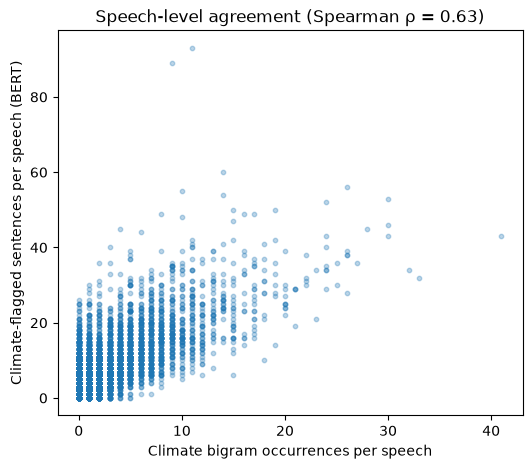

In [98]:
rho, p = spearmanr(df_clean["bigrams_count"], df_clean["BERT_sentence_count"])
print(f"Spearman rho = {rho:.2f} (p = {p:.3g})")

print(pd.crosstab(df_clean["bigrams_any"], df_clean["BERT_any"],
                  rownames=["Bigrams"], colnames=["BERT"], margins=True))
print("Raw agreement:", round((df_clean["bigrams_any"] == df_clean["BERT_any"]).mean(), 2))
print("Cohen's kappa:", round(cohen_kappa_score(df_clean["bigrams_any"], df_clean["BERT_any"]), 2))

# Length check: how much does each count simply follow speech length?
for col in ["bigrams_count", "BERT_sentence_count"]:
    r, _ = spearmanr(df_clean[col], df_clean["total_tokens"])
    print(f"{col} vs speech length: rho = {r:.2f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_clean["bigrams_count"], df_clean["BERT_sentence_count"], s=10, alpha=0.3)
ax.set_xlabel("Climate bigram occurrences per speech")
ax.set_ylabel("Climate-flagged sentences per speech (BERT)")
ax.set_title(f"Speech-level agreement (Spearman ρ = {rho:.2f})")
plt.show()

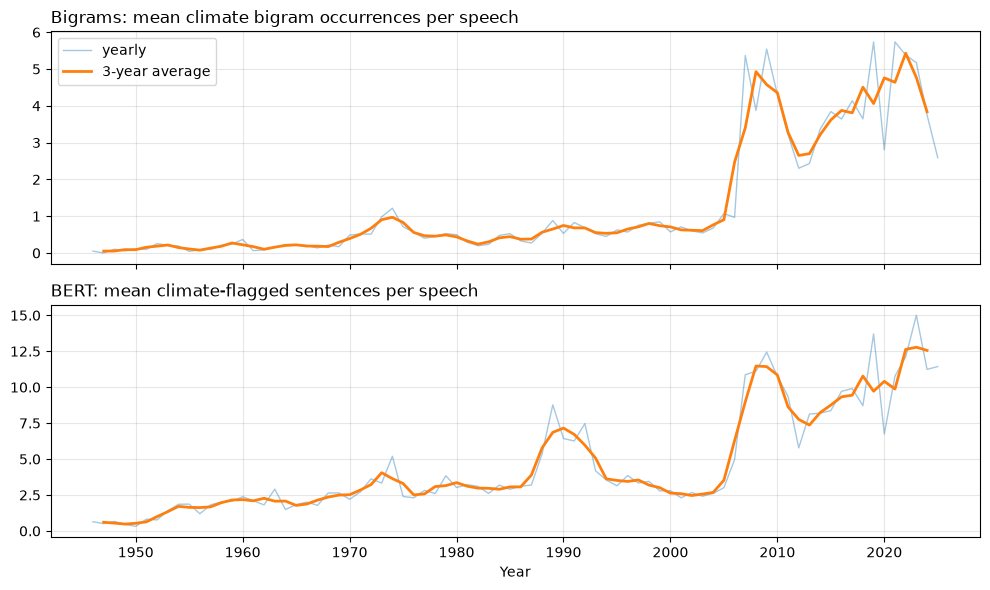

Yearly levels  rho: 0.87
Yearly changes rho: 0.33


In [99]:
yearly = df_clean.groupby(level="year")[["bigrams_count", "BERT_sentence_count"]].mean()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
panels = [("bigrams_count", "Bigrams: mean climate bigram occurrences per speech"),
          ("BERT_sentence_count", "BERT: mean climate-flagged sentences per speech")]
for ax, (col, title) in zip(axes, panels):
    ax.plot(yearly.index, yearly[col], linewidth=1, alpha=0.4, label="yearly")
    ax.plot(yearly.index, yearly[col].rolling(3, center=True).mean(), linewidth=2, label="3-year average")
    ax.set_title(title, loc="left")
    ax.grid(alpha=0.3)
axes[0].legend(loc="upper left")
axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.show()

print("Yearly levels  rho:", round(yearly.corr(method="spearman").iloc[0, 1], 2))
print("Yearly changes rho:", round(yearly.diff().corr(method="spearman").iloc[0, 1], 2))

In [100]:
df_clean["rank_bigrams"] = df_clean["bigrams_count"].rank(pct=True)
df_clean["rank_BERT"]    = df_clean["BERT_sentence_count"].rank(pct=True)
df_clean["gap"] = df_clean["rank_BERT"] - df_clean["rank_bigrams"]

cols = ["bigrams_count", "BERT_sentence_count", "total_sentences", "tokens_per_sentence"]
print("BERT high, bigrams low:")
display(df_clean.sort_values("gap", ascending=False)[cols].head(10))
print("Bigrams high, BERT low:")
display(df_clean.sort_values("gap")[cols].head(10))

BERT high, bigrams low:


,,bigrams_count,BERT_sentence_count,total_sentences,tokens_per_sentence
year,country,,,,
1978,SGP,0.0,26.0,104.0,17.673077
1979,USA,0.0,25.0,140.0,16.028571
1957,IND,0.0,25.0,381.0,17.435696
2022,BRA,0.0,25.0,107.0,12.317757
2023,MWI,0.0,24.0,48.0,15.125000
1986,BEL,0.0,23.0,124.0,16.387097
2008,SEN,0.0,23.0,104.0,10.701923
2024,UKR,0.0,22.0,82.0,10.341463
1988,RUS,0.0,21.0,172.0,18.087209


Bigrams high, BERT low:


,,bigrams_count,BERT_sentence_count,total_sentences,tokens_per_sentence
year,country,,,,
1973,PAN,5.0,0.0,48.0,37.020833
1975,PAN,5.0,0.0,45.0,45.400000
1979,STP,4.0,0.0,72.0,42.055556
1980,SDN,4.0,0.0,112.0,20.687500
1973,LBY,4.0,0.0,48.0,24.041667
1979,RWA,3.0,0.0,46.0,46.304348
1978,BEN,3.0,0.0,79.0,36.569620
1965,EGY,3.0,0.0,187.0,14.598930
1979,YEM,3.0,0.0,67.0,30.388060


Comparing the two methods

To check whether both methods measure the same thing, we compared the number of climate bigrams and the number of BERT-flagged climate sentences in each speech. We used the Spearman correlation because the two measures count different things (phrases vs. sentences), most speeches have very low or zero counts while a few have very high ones, and we only care whether both methods rank the speeches in the same order, not whether they match exactly.

The results show a strong agreement (rho = 0.63): speeches that one method sees as very focused on climate, the other usually does too. Over time the agreement is even stronger (ρ = 0.87 for yearly averages), and both methods show the same sharp rise in climate talk after 2005. The main difference is at the low end: BERT flags climate content in about 90% of speeches, while bigrams do so in about 63%. BERT is broader, and bigrams are stricter but miss paraphrases. Overall, our conclusions about climate talk do not depend on which method we use.